## Spotify Mood Playlist Generator Project by Stavroula Despoina Alexandropoulou

**This project aims to analyze a dataset that contains Spotify's Top Songs since 2016 with unsupervised machine learning models. Apart from each song's title, number of streams and number of weeks on the charts, it contains information about its audio features, such as valence, danceability and more; features that can describe the emotional and musical characteristics of a song. The main goal of this project is to group songs into playlists by applying KMeans clustering to selected audio features, creating distinct music playlists, one for every mood. **

### How to run the dataset:

##### Step 1: Please, make sure to download and place the dataset file `spotify_top_songs_audio_features.csv` that you will find on my GitHub repository, at the same folder as the notebook.


##### Step 2: Run the cells in the order you see them, from top to bottom.

##### The code will:
1) load and inspect the dataset
2) clean and transform the data
3) scale selected audio features
4) do KMeans clustering
5) generate mood-based song playlists
6) export the playlist in a form of CSV

# !!!! add pipeline image here

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
sns.set()  # for plot styling
from sklearn.preprocessing import StandardScaler


**For starters, let's import the CSV! The CSV's name is Spotify Top Songs and Audio Features and it was derived from Kaggle. You can find it in this link: https://www.kaggle.com/datasets/julianoorlandi/spotify-top-songs-and-audio-features**

In [2]:
try:
    spotify_df = pd.read_csv('spotify_top_songs_audio_features.csv')
    print("Dataset loaded successfully!")
except FileNotFoundError:
    print("File not found! Pls try again!")

Dataset loaded successfully!


In [3]:
spotify_df.to_csv('spotify_raw_data_saved.csv', index=False) # Save a local copy of the raw dataset for reproducibility 

**Now, let's check what information this dataset contains. I also want to check which columns are numeric and inspect and handle any possible null values.**

In [4]:
display(spotify_df.head())

,id,artist_names,track_name,source,key,mode,time_signature,danceability,energy,speechiness,acousticness,instrumentalness,liveness,valence,loudness,tempo,duration_ms,weeks_on_chart,streams
0,000xQL6tZNLJzIrtIgxqSl,"ZAYN, PARTYNEXTDOOR",Still Got Time (feat. PARTYNEXTDOOR),RCA Records Label,G,Major,4 beats,0.748,0.627,0.0639,0.13100,0.0,0.0852,0.524,-6.029,120.963,188491,17,107527761
1,003eoIwxETJujVWmNFMoZy,Alessia Cara,Growing Pains,Def Jam Recordings,C#/Db,Minor,4 beats,0.353,0.755,0.7330,0.08220,0.0,0.3900,0.437,-6.276,191.153,193680,2,9944865
2,003vvx7Niy0yvhvHt4a68B,The Killers,Mr. Brightside,Island Records,C#/Db,Major,4 beats,0.352,0.911,0.0747,0.00121,0.0,0.0995,0.236,-5.230,148.033,222973,125,512388123
3,00B7TZ0Xawar6NZ00JFomN,"Cardi B, Chance the Rapper",Best Life (feat. Chance The Rapper),Atlantic/KSR,A,Major,4 beats,0.620,0.625,0.5530,0.28700,0.0,0.3140,0.665,-7.438,167.911,284856,2,11985346
4,00Blm7zeNqgYLPtW6zg8cj,"Post Malone, The Weeknd",One Right Now (with The Weeknd),Republic Records,C#/Db,Major,4 beats,0.687,0.781,0.0530,0.03610,0.0,0.0755,0.688,-4.806,97.014,193507,30,301860377


##### ---------- Information on the dataset --------------

In [5]:
spotify_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6513 entries, 0 to 6512
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id                6513 non-null   object 
 1   artist_names      6513 non-null   object 
 2   track_name        6513 non-null   object 
 3   source            6513 non-null   object 
 4   key               6513 non-null   object 
 5   mode              6513 non-null   object 
 6   time_signature    6513 non-null   object 
 7   danceability      6513 non-null   float64
 8   energy            6513 non-null   float64
 9   speechiness       6513 non-null   float64
 10  acousticness      6513 non-null   float64
 11  instrumentalness  6513 non-null   float64
 12  liveness          6513 non-null   float64
 13  valence           6513 non-null   float64
 14  loudness          6513 non-null   float64
 15  tempo             6513 non-null   float64
 16  duration_ms       6513 non-null   int64  


In [6]:
print("Dataset shape:", spotify_df.shape)

Dataset shape: (6513, 19)


##### -------------- Descriptive Statistics ---------------

In [7]:
spotify_df.describe()

,danceability,energy,speechiness,acousticness,instrumentalness,liveness,valence,loudness,tempo,duration_ms,weeks_on_chart,streams
count,6513.000000,6513.000000,6513.000000,6513.000000,6513.000000,6513.000000,6513.000000,6513.000000,6513.000000,6513.000000,6513.000000,6.513000e+03
mean,0.681731,0.636522,0.121933,0.236761,0.012469,0.180168,0.492412,-6.350667,122.117244,202566.684170,13.614924,1.089647e+08
std,0.141787,0.164813,0.113441,0.244784,0.075151,0.138054,0.227001,2.536114,29.416097,49199.592333,24.084051,2.276695e+08
min,0.150000,0.021800,0.023200,0.000008,0.000000,0.019700,0.032000,-34.475000,46.718000,30133.000000,1.000000,2.525159e+06
25%,0.591000,0.534000,0.044000,0.044400,0.000000,0.097400,0.316000,-7.564000,98.007000,173038.000000,1.000000,8.695060e+06
50%,0.698000,0.651000,0.072200,0.145000,0.000000,0.124000,0.489000,-5.983000,120.034000,198367.000000,4.000000,2.712856e+07
75%,0.785000,0.759000,0.163000,0.356000,0.000041,0.219000,0.669000,-4.673000,142.025000,226003.000000,16.000000,9.951456e+07
max,0.985000,0.989000,0.966000,0.994000,0.953000,0.977000,0.982000,1.509000,212.117000,690732.000000,367.000000,3.528450e+09


##### ------------ Check for Missing and Duplicate Values -------------

In [8]:
spotify_df.isnull().sum()

id                  0
artist_names        0
track_name          0
source              0
key                 0
mode                0
time_signature      0
danceability        0
energy              0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
loudness            0
tempo               0
duration_ms         0
weeks_on_chart      0
streams             0
dtype: int64

In [9]:
print("Duplicate rows:", spotify_df.duplicated().sum())

Duplicate rows: 0


**So, what are we looking at? The Spotify Top Songs and Audio Features Dataset contains 6513 rows, each one representing a unique song. It also features 19 columns, each representing a feature of the song. Since our aim is to distribute these songs into different mood playlists, we need to be able to compare them based on their audio features. For this reason, we will be using the columns that contain numerical audio features for clustering, such as valence, danceability, etc. Also, inspection of the dataset showed that there are no missing values and no duplicate rows, meaning the dataset is already relatively clean and requires minimal preprocessing before analysis.**

In [10]:
features = ['danceability', 'energy', 'valence', 'acousticness', 'loudness', 'tempo']

**The features will be the ones defining the mood. Valence shows how happy a songs is, loudness and energy cover a song's intensity, danceability and tempo show how able it would be for a person to move to the rhythm of that song.**

##### Exploring Relationships Between Audio Features

Before clustering the songs, I want to check how the selected audio features relate to each other. This will help understand whether some features move together and whether they can be useful for creating mood-based playlists.

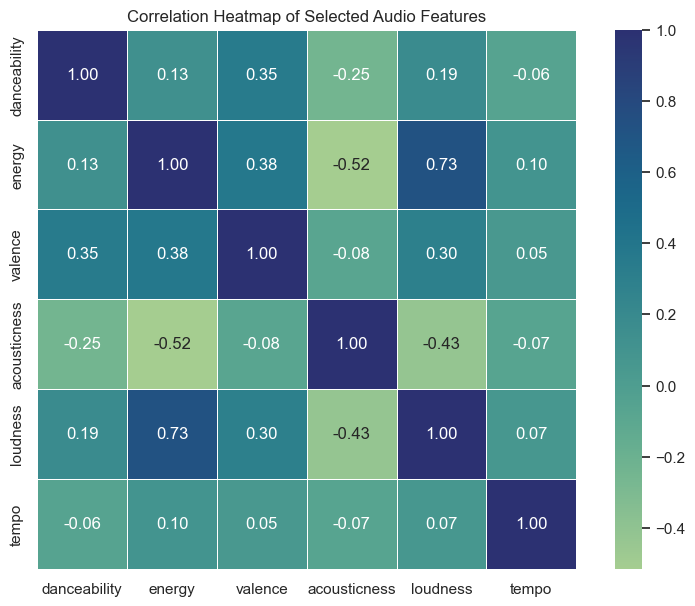

In [11]:
plt.figure(figsize=(10, 7))

correlation_matrix = spotify_df[features].corr()

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='crest',
    fmt='.2f',
    linewidths=0.5,
    square=True
)

plt.title('Correlation Heatmap of Selected Audio Features')
plt.show()

From the heatmap, we can tell that the strongest positive relationship is between energy and loudness (0.73). This makes sense because louder songs usually feel more energetic. 

Acousticness has a negative relationship with energy and loudness, meaning that more acoustic songs tend to be softer and less intense. Danceability and valence also have a small positive relationship, which suggests that happier songs can often be easier to dance to.

To understand these relationships better, we will visualize some of the most useful feature pairs from the heatmap. We will take a look at energy vs loudness, because they had the strongest positive correlation, and danceability vs valence, because both features are important for describing the mood of a song.

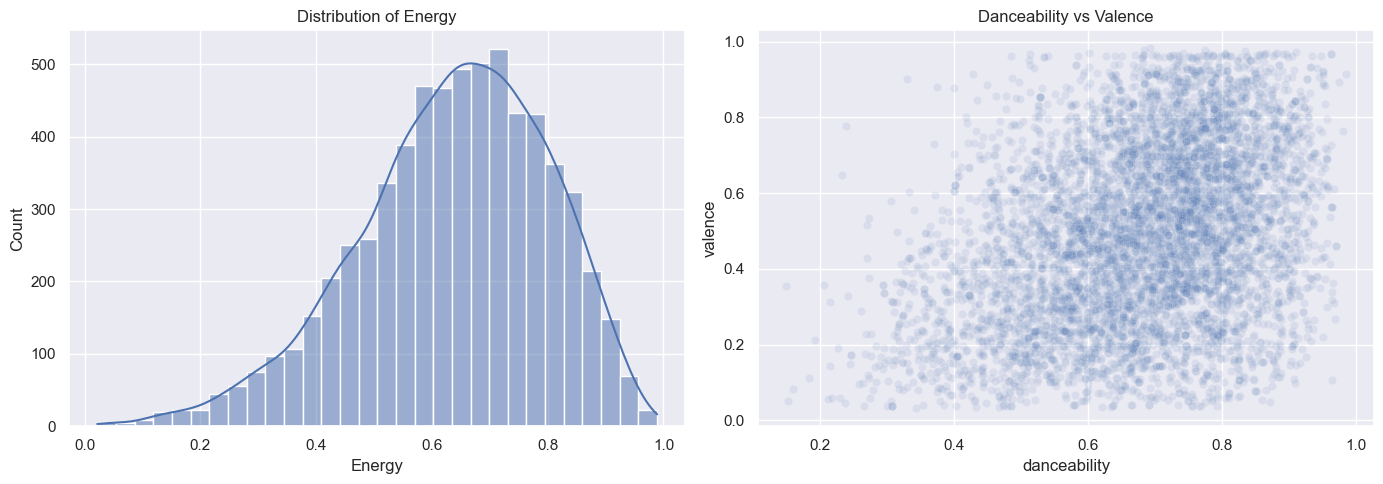

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Energy distribution
sns.histplot(
    spotify_df['energy'], bins=30, kde=True, ax=axes[0])

axes[0].set_title('Distribution of Energy')
axes[0].set_xlabel('Energy')

# Danceability vs Valence
sns.scatterplot( data=spotify_df,x='danceability',y='valence', alpha=0.1, ax=axes[1]) #alpha is set at 0.1 because it will help us see trends more easily in the scatterplot. with over 6000 songs in the dataset, a higher alpha makes us unable to distinguish a trend.

axes[1].set_title('Danceability vs Valence')

plt.tight_layout()
plt.show()

The energy distribution shows that most songs in the dataset have medium to high energy values, while very low-energy songs are less common. This suggests that many songs in the dataset have a more active and dynamic sound.

The Danceability vs Valence plot shows a slight positive relationship, but the points are still very spread out. This means that happier songs can sometimes be more danceable, but mood cannot be explained by only one feature pair. Because of this, it makes sense to use multiple audio features together for clustering.

## Scaling the data

In [13]:
clustering_dataset = spotify_df[features]

In [14]:
clustering_dataset

,danceability,energy,valence,acousticness,loudness,tempo
0,0.748,0.627,0.524,0.13100,-6.029,120.963
1,0.353,0.755,0.437,0.08220,-6.276,191.153
2,0.352,0.911,0.236,0.00121,-5.230,148.033
3,0.620,0.625,0.665,0.28700,-7.438,167.911
4,0.687,0.781,0.688,0.03610,-4.806,97.014
...,...,...,...,...,...,...
6508,0.615,0.779,0.453,0.06650,-6.454,160.000
6509,0.767,0.313,0.765,0.83800,-12.059,82.582
6510,0.924,0.730,0.848,0.05250,-6.125,99.010
6511,0.727,0.530,0.258,0.28300,-8.616,174.025


In [15]:
scaler = StandardScaler()

In [16]:
clustering_dataset = scaler.fit_transform(clustering_dataset)

In [17]:
clustering_dataset

array([[ 0.46742128, -0.05778086,  0.13916583, -0.43209088,  0.12684413,
        -0.03924152],
       [-2.31865592,  0.71891872, -0.24412251, -0.6314653 ,  0.02944356,
         2.34705024],
       [-2.32570928,  1.66552132, -1.12965074, -0.9623533 ,  0.4419172 ,
         0.88107359],
       ...,
       [ 1.70881264,  0.56721958,  1.56658447, -0.75280589,  0.08898804,
        -0.7855909 ],
       [ 0.31930072, -0.6463735 , -1.03272725,  0.18891141, -0.8932986 ,
         1.76473929],
       [ 0.43920784,  0.4762001 , -0.67146698, -0.55465713,  0.09766339,
         1.11664299]], shape=(6513, 6))

In [18]:
clustering_dataset = pd.DataFrame(clustering_dataset, columns=features, index=spotify_df.index) #let's convert the scaled array back into a DataFrame for easier inspection

In [19]:
clustering_dataset

,danceability,energy,valence,acousticness,loudness,tempo
0,0.467421,-0.057781,0.139166,-0.432091,0.126844,-0.039242
1,-2.318656,0.718919,-0.244123,-0.631465,0.029444,2.347050
2,-2.325709,1.665521,-1.129651,-0.962353,0.441917,0.881074
3,-0.435409,-0.069917,0.760357,0.205254,-0.428773,1.556878
4,0.037166,0.876686,0.861686,-0.819809,0.609115,-0.853450
...,...,...,...,...,...,...
6508,-0.470676,0.864550,-0.173633,-0.695608,-0.040748,1.287923
6509,0.601435,-1.963122,1.200919,2.456387,-2.250991,-1.344104
6510,1.708813,0.567220,1.566584,-0.752806,0.088988,-0.785591
6511,0.319301,-0.646374,-1.032727,0.188911,-0.893299,1.764739


After scaling, the values are centered around 0 and transformed to a similar scale. This will help KMeans treat all features more fairly during clustering.
**Now that all of our data is in the same form, we can actually implement ML models efficiently!**

In [20]:
from sklearn.cluster import KMeans

##### Finding the optimal number of clusters using the Elbow Method

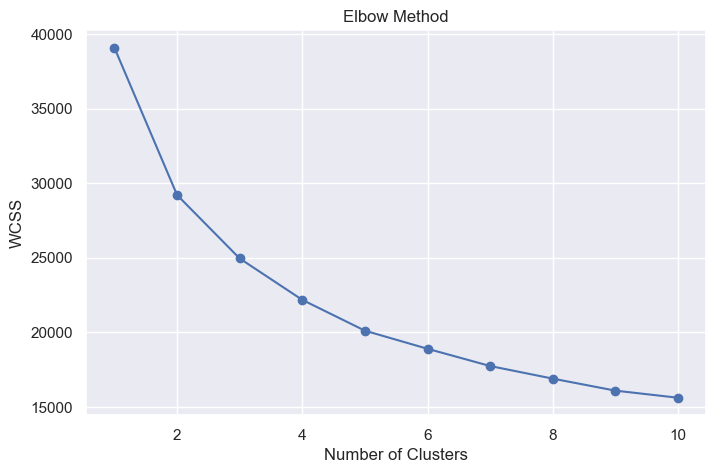

In [28]:
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(clustering_dataset)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')

plt.show()

From the Elbow Method graph, the WCSS decreases rapidly between 1 and 3 clusters, while after that point the decrease becomes more gradual. This suggests that the main structure of the data is already captured with around 3 clusters.

Although the elbow is not perfectly sharp, k=3 appears to be a reasonable choice because it balances simplicity and meaningful separation between songs.

For this reason, we will continue the analysis using 3 clusters.

In [33]:
kmeans = KMeans(n_clusters=3)
kmeans.fit(clustering_dataset)
y_kmeans=kmeans.predict(clustering_dataset)

**We trained our model and now assigned each song to a cluster. Let's visualise it and make sure this is right!**

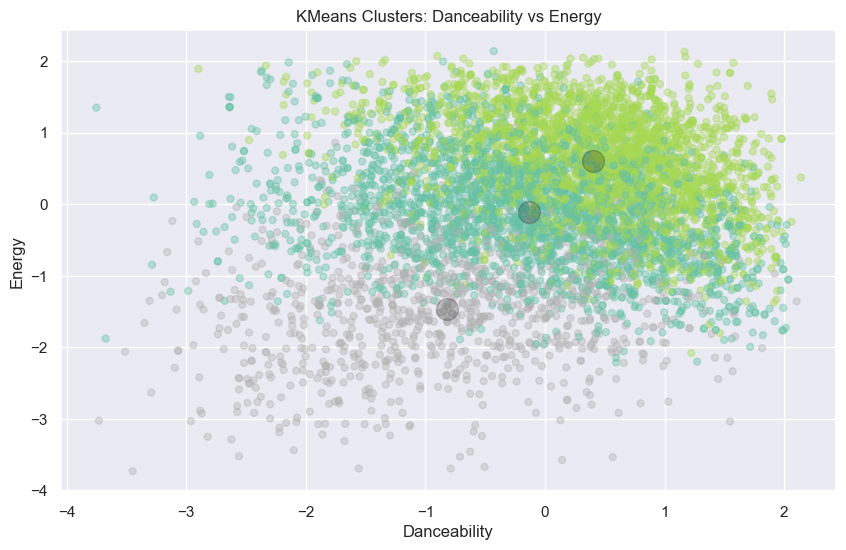

In [50]:
plt.figure(figsize=(10, 6))
plt.scatter(clustering_dataset['danceability'], clustering_dataset['energy'], c=y_kmeans, s=25, cmap='Set2', alpha = 0.4)

centers = kmeans.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c='black', s=250, alpha=0.2)

plt.xlabel('Danceability')
plt.ylabel('Energy')
plt.title('KMeans Clusters: Danceability vs Energy')
plt.show()

Visualising the clusters using only two features can be useful, but it does not fully represent the structure of the dataset, since KMeans was trained using all selected audio features.

For this reason, we will also use Principal Component Analysis (PCA) to reduce the dataset into two dimensions whileusing all 6 features. This will help visualise how the clusters are separated in the full feature space.

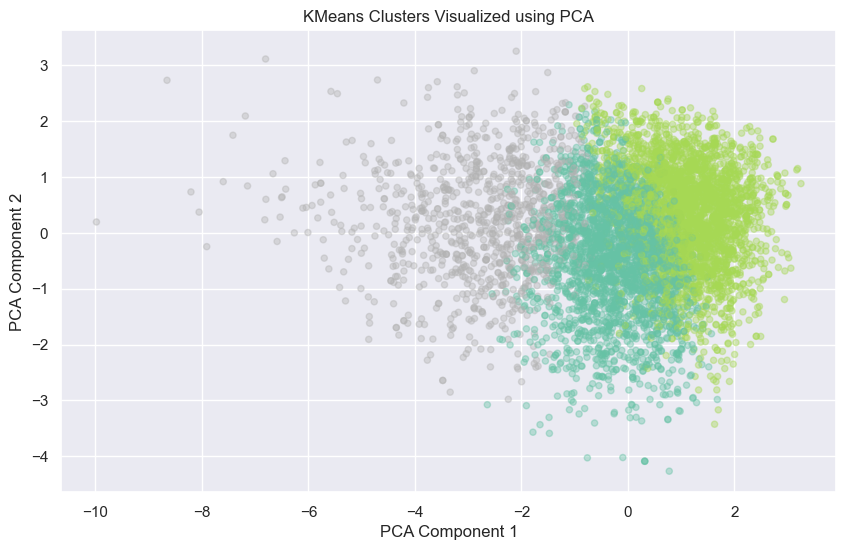

In [62]:
from sklearn.decomposition import PCA
plt.figure(figsize=(10, 6))

plt.scatter(points_2d[:, 0], points_2d[:, 1], c=y_kmeans, cmap='Set2', s=20, alpha=0.4)

plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title('KMeans Clusters Visualized using PCA')

plt.show()


The PCA visualisation shows that the KMeans algorithm was able to separate the songs into three different groups. While some overlap between clusters still exists, distinct regions can still be observed.

This is expected because music features are naturally continuous and many songs may share similar characteristics. Overall, the clustering results suggest that the selected audio features are useful for grouping songs based on mood and musical style.

In [63]:
spotify_df['cluster'] = y_kmeans

In [64]:
spotify_df.groupby('cluster')[['danceability','energy','valence','acousticness','loudness','tempo']].mean()

,danceability,energy,valence,acousticness,loudness,tempo
cluster,,,,,,
0,0.663017,0.619136,0.336582,0.145279,-6.536596,123.652220
1,0.739326,0.736133,0.680960,0.175863,-4.990743,123.077948
2,0.565540,0.395082,0.367673,0.660388,-9.785927,115.186131


Cluster 0: medium danceability and energy, but lower valence and low acousticness. -> Darker and more intense style of music with a more emotional mood.

Cluster 1: the highest danceability, energy and valence, while also having the highest loudness -> More upbeat, energetic and party-like songs.

Cluster 2: highest acousticness, lowest energy and lowest loudness. This suggests a calmer, softer and more acoustic style of playlist.

In [66]:
spotify_df['playlist_name'] = spotify_df['cluster'].map({0: 'Dark, Intense Vibe', 1: 'Party Feel-Good Vibe', 2: 'Chill Vibe'})

In [67]:
new_spotify_df=spotify_df[['id','track_name', 'artist_names', 'cluster', 'playlist_name']]

In [68]:
new_spotify_df.head()

,id,track_name,artist_names,cluster,playlist_name
0,000xQL6tZNLJzIrtIgxqSl,Still Got Time (feat. PARTYNEXTDOOR),"ZAYN, PARTYNEXTDOOR",0,"Dark, Intense Vibe"
1,003eoIwxETJujVWmNFMoZy,Growing Pains,Alessia Cara,0,"Dark, Intense Vibe"
2,003vvx7Niy0yvhvHt4a68B,Mr. Brightside,The Killers,0,"Dark, Intense Vibe"
3,00B7TZ0Xawar6NZ00JFomN,Best Life (feat. Chance The Rapper),"Cardi B, Chance the Rapper",1,Party Feel-Good Vibe
4,00Blm7zeNqgYLPtW6zg8cj,One Right Now (with The Weeknd),"Post Malone, The Weeknd",1,Party Feel-Good Vibe


In [69]:
dark_playlist = new_spotify_df[new_spotify_df['playlist_name']=='Dark, Intense Vibe']
party_playlist = new_spotify_df[new_spotify_df['playlist_name']=='Party Feel-Good Vibe']
chill_playlist = new_spotify_df[new_spotify_df['playlist_name']=='Chill Vibe']


In [70]:
chill_playlist.to_csv('chill_playlist.csv', index=False)
party_playlist.to_csv('party_playlist.csv', index=False)
dark_playlist.to_csv('dark_playlist.csv', index=False)

In [77]:
pip install python-dotenv

In [78]:
import os
from dotenv import load_dotenv
import spotipy
from spotipy.oauth2 import SpotifyClientCredentials

# Load environment variables
load_dotenv()

# Get Spotify API credentials from .env file
CLIENT_ID = os.getenv("SPOTIFY_CLIENT_ID")
CLIENT_SECRET = os.getenv("SPOTIFY_CLIENT_SECRET")

# Spotify API authentication
sp = spotipy.Spotify(
    auth_manager=SpotifyClientCredentials(
        client_id=CLIENT_ID,
        client_secret=CLIENT_SECRET
    )
)

SpotifyOauthError: No client_id. Pass it or set a SPOTIPY_CLIENT_ID environment variable.

In [75]:
def get_track_metadata(track_name, artist_name):
    
    query = f"track:{track_name} artist:{artist_name}"
    
    results = sp.search(q=query, type='track', limit=1)
    
    items = results['tracks']['items']
    
    if len(items) == 0:
        return None, None
    
    track = items[0]
    
    release_date = track['album']['release_date']
    spotify_url = track['external_urls']['spotify']
    
    return release_date, spotify_url

In [ ]:
metadata = new_spotify_df.apply(
    lambda row: get_track_metadata(
        row['track_name'],
        row['artist_names']
    ),
    axis=1
)

new_spotify_df[['release_date', 'spotify_url']] = pd.DataFrame(
    metadata.tolist(),
    index=new_spotify_df.index
)

In [ ]:
new_spotify_df.head()